# Notebook 03C — Pré-Processamento (Desenho 3: intra-artrite)

**Projeto:** Mineração de Dados em Saúde · PNS 2019 — **Pesquisador:** Pedro Dias Soares —
**Orientador:** Prof. Dr. Luis Enrique Zárate (PUC Minas)

---

## O que muda em relação ao NB03/03b

| | NB03 (D1) | NB03b (D2) | **NB03c (D3 — este)** |
|---|---|---|---|
| Coorte | artrite pura vs saudáveis | artrite c/comorb vs saudáveis | **só idosos com artrite** |
| Alvo (`Label`) | tem artrite | tem artrite | **tem ≥1 comorbidade** (1=c/comorb, 0=pura) |
| Objetivo | dieta ↔ artrite | idem (mais poder) | **dieta ↔ carga de comorbidade, segurando a artrite constante** |

O Desenho 3 segura a artrite constante para **reduzir a causalidade reversa** que contamina D1/D2.
⚠️ **Confundidor declarado:** parte do sinal alimentar pode refletir o *manejo dietético* da comorbidade
(hipertensão/diabetes), não a artrite. Por isso trabalhamos com **dupla contagem** (total e não-dietética)
e a entrega central é o **gradiente IRNI × carga**, não o classificador. Ver `docs/spec_nutricao_desenho3.md`.

Todo o pré-processamento (skip patterns, missing, outliers, imputação global target-blind, encoding) é
**idêntico ao NB03b**. As peças novas (IRNI, contagem de comorbidades) vêm do módulo `nutricao.py`.

## 1 · Configuração (reusa config.toml + módulo nutricao.py)

In [1]:
import sqlite3, os, math, warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nutricao  # módulo local (notebooks/nutricao.py): IRNI, cluster, comorbidades

[warnings.filterwarnings('ignore', category=c) for c in (FutureWarning, DeprecationWarning, UserWarning)]

PASTA_DB       = '../data/database/'
DIR_RESULTADOS = '../data/results/preprocessing_desenho3/'   # pasta própria do D3
DIR_FIGURAS    = DIR_RESULTADOS + 'figuras/'
DIR_TABELAS    = DIR_RESULTADOS + 'tabelas/'
for pasta in [DIR_RESULTADOS, DIR_FIGURAS, DIR_TABELAS]:
    os.makedirs(pasta, exist_ok=True)

try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib
with open('../config.toml', 'rb') as _f:
    CFG = tomllib.load(_f)
RANDOM_STATE    = CFG['pipeline']['random_state']
ALPHA           = CFG['pipeline']['alpha']
LIMITE_MISSING  = CFG['pipeline']['limite_missing']
LIMITE_IQR_MULT = CFG['pipeline']['limite_iqr_mult']
COR_ARTRITE  = CFG['cores']['artrite']
COR_SAUDAVEL = CFG['cores']['saudavel']

# Pesos do IRNI (dois esquemas) e comorbidades de manejo dietético — do config.toml
PESOS_GRADED  = nutricao.pesos_irni(CFG, 'graded')
PESOS_DIRECAO = nutricao.pesos_irni(CFG, 'direcao')
DIETETICAS    = CFG['nutricao']['desenho3']['comorbidades_dieteticas']

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

def salvar_fig(nome):
    plt.savefig(DIR_FIGURAS + nome, dpi=150, bbox_inches='tight'); print(f'  ✅ Figura → {DIR_FIGURAS+nome}')
def salvar_tab(df, nome):
    df.to_csv(DIR_TABELAS + nome, encoding='utf-8-sig'); print(f'  ✅ Tabela → {DIR_TABELAS+nome}')

print('✅ Ambiente configurado. IRNI esquemas:', list(CFG['nutricao']['irni']))
print('   Comorbidades dietéticas (excluídas da contagem não-dietética):', DIETETICAS)

✅ Ambiente configurado. IRNI esquemas: ['padronizar', 'itens_frequencia', 'graded', 'direcao']
   Comorbidades dietéticas (excluídas da contagem não-dietética): ['Q00201', 'Q03001', 'Q060', 'Q06306']


In [ ]:
# ── Bootstrap dos bancos (.db) — regenera se faltar ───────────────────────────
# Os arquivos .db/.csv são gitignored (dados NÃO versionados, por opção do projeto).
# Esta célula garante que os bancos lidos abaixo existam: se faltarem, são
# reconstruídos a partir dos CSVs-semente em data/processed/csv/.
# É idempotente — não faz nada (rápido) quando os bancos já estão ok.
import sys as _sys, os as _os
for _p in (_os.getcwd(), _os.path.join(_os.getcwd(), 'notebooks')):
    if _os.path.isfile(_os.path.join(_p, 'preparar_bancos.py')) and _p not in _sys.path:
        _sys.path.insert(0, _p)
from preparar_bancos import garantir_bancos
garantir_bancos(['idosos_artrite.db'])


## 2 · Definição das variáveis (idênticas ao NB03b)

In [2]:
VARS_CONTINUAS = ['P00104','P00404','VDF004']
VARS_DISCRETAS = ['C008','P035','P04501','P00901','P015','P018','P01101','P02501','P02002',
                  'P02001','P023','P01601','P02602','P006','P013','J012','P02801','P029','P03202']
VARS_NOMINAIS = ['C006','P034','I00102','J01101','J01002','G059','G060','G062','Q092','Q11006',
                 'Q00201','Q03001','Q060','Q06306','Q068','Q084','Q074','Q120','Q124','Q11604',
                 'P00603','P00620','P02601','P027','P03201','P02401','P02101','P02102','P00612',
                 'P00614','P00615','P00616','Q04708','Q047081','Q04711','Q047111']
VARS_ORDINAIS = ['VDD004A','N001','N010','N011','G070','Q115','Q109','G079','G080','G081','Q05901']
TODAS_VARS = VARS_CONTINUAS + VARS_DISCRETAS + VARS_NOMINAIS + VARS_ORDINAIS + ['Q079']
print('Variáveis definidas. Total features candidatas:',
      len(VARS_CONTINUAS+VARS_DISCRETAS+VARS_NOMINAIS+VARS_ORDINAIS))

Variáveis definidas. Total features candidatas: 69


## 3 · Carregamento — só a coorte com artrite

Carrega **apenas** `idosos_artrite.db` (todos os idosos com Q079=Sim = puros + com comorbidade).
O alvo do D3 NÃO vem do arquivo, e sim da **contagem de comorbidades** (próxima célula).

In [3]:
print('Executando a partir de:', os.getcwd())
colunas_sql = list(dict.fromkeys(['V0015', 'M001'] + TODAS_VARS))
SQL = f"SELECT {', '.join(colunas_sql)} FROM pns_idosos"

caminho = PASTA_DB + 'idosos_artrite.db'
assert os.path.exists(caminho), (f'{caminho} não encontrado. O D3 usa a base de TODOS os idosos com '
    'artrite (idosos_artrite.db, gerada pelo NB01). Rode o NB01 ou copie data/database/.')
conn = sqlite3.connect(caminho); df_raw = pd.read_sql_query(SQL, conn); conn.close()
n_bruto = len(df_raw)

# Filtros de integridade (iguais ao NB03b)
for flag in ['V0015','M001']:
    if flag in df_raw.columns:
        df_raw[flag] = df_raw[flag].replace({'nan': pd.NA, 'None': pd.NA, '': pd.NA})
        cobertura_ok = (df_raw[flag].notna().sum() > 0) if flag=='V0015' else (df_raw[flag].notna().mean() >= 0.10)
        if cobertura_ok:
            mask = (pd.to_numeric(df_raw[flag], errors='coerce') == 1) | \
                   df_raw[flag].astype(str).str.strip().str.lower().isin(['1','01','realizada','sim'])
            df_raw = df_raw[mask]
df_raw = df_raw.drop(columns=['V0015','M001'], errors='ignore').reset_index(drop=True)
print(f'  📦 idosos_artrite.db: {n_bruto:,} bruto → {len(df_raw):,} válidos')

Executando a partir de: d:\Faculdade\Semestre 3\Mineração de Dados\Python\Projeto\Projeto_PNS\notebooks
  📦 idosos_artrite.db: 4,025 bruto → 4,025 válidos


## 4 · ⭐ Alvo do Desenho 3 + contagem de comorbidades

`Label = 1` se o idoso tem ≥1 comorbidade (além da artrite); `0` se artrite isolada.
Guardamos **duas contagens** (via `nutricao.contar_comorbidades`): `n_comorb_total` e
`n_comorb_naodieteticas` (excluindo hipertensão/diabetes/colesterol/cardíaca). Elas são **derivadas do
alvo** → ficam de fora das features (anti-leakage), entrando só na análise de gradiente (Etapa final).

In [4]:
n_total, n_naodiet, indicadores = nutricao.contar_comorbidades(df_raw, DIETETICAS)
meta = pd.DataFrame({'n_comorb_total': n_total, 'n_comorb_naodieteticas': n_naodiet}, index=df_raw.index)
df_raw['Label'] = (n_total >= 1).astype(int)
df_raw['Classe'] = np.where(df_raw['Label'] == 1, 'Artrite c/comorb', 'Artrite pura')  # p/ reusar plots/outliers

vc = df_raw['Label'].value_counts()
print('  Alvo D3 (1 = tem comorbidade):')
print(f'    1 (c/comorbidade): {int(vc.get(1,0)):,}')
print(f'    0 (artrite pura) : {int(vc.get(0,0)):,}')
print(f'    razão            : {vc.max()/max(vc.min(),1):.2f}:1  ⚠️ desbalanceado (minoria=pura)')
print(f'  Carga de comorbidade: média total={n_total.mean():.2f} | média não-dietética={n_naodiet.mean():.2f}')

  Alvo D3 (1 = tem comorbidade):
    1 (c/comorbidade): 3,434
    0 (artrite pura) : 591
    razão            : 5.81:1  ⚠️ desbalanceado (minoria=pura)
  Carga de comorbidade: média total=2.03 | média não-dietética=0.58


## 5 · Conversão de tipos (idêntica ao NB03b)

In [5]:
VARS_NUMERICAS = VARS_CONTINUAS + VARS_DISCRETAS
import unicodedata
def _norm(v):
    s = str(v).strip().lower().replace('¼','1/4').replace('½','1/2').replace('¾','3/4')
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(c for c in s if not unicodedata.combining(c)).replace('⁄','/')
    return ' '.join(s.split())
MAPA_ORDINAL = CFG['mapas']['ordinal']; MAPA_VDF004 = CFG['mapas']['vdf004']; MAPA_PAIS = CFG['mapas']['pais']

def coerce_codificado(serie, mapa):
    num = pd.to_numeric(serie, errors='coerce')
    if mapa:
        falta = serie[num.isna() & serie.notna()]
        if len(falta):
            num = num.fillna(pd.to_numeric(falta.map(lambda v: mapa.get(_norm(v))), errors='coerce'))
        num = num.where(num.isin(set(mapa.values())))
    rest = serie[num.isna() & serie.notna()].map(_norm)
    nao_map = sorted(set(rest) - {'ignorado','nao aplicavel','9','99','nan',''})
    return num, nao_map

if 'VDF004' in df_raw.columns:
    df_raw['VDF004'], _nm = coerce_codificado(df_raw['VDF004'], MAPA_VDF004)
    if _nm: print('  [aviso] VDF004 rótulos não mapeados: ' + str(_nm[:8]))

VARS_FREQ_TEXTO = CFG['frequencia']['vars']
def coerce_frequencia(serie):
    num = pd.to_numeric(serie, errors='coerce')
    falta = serie[num.isna() & serie.notna()]
    if len(falta):
        num = num.fillna(falta.map(lambda v: 0.0 if _norm(v).startswith(CFG['frequencia']['zero_label_prefix']) else float('nan')))
    return num
for col in VARS_NUMERICAS:
    if col not in df_raw.columns: continue
    if col == 'P04501':
        direto = pd.to_numeric(df_raw[col], errors='coerce')
        via_regex = df_raw[col].astype(str).str.extract(r'(\d+\.?\d*)')[0]
        df_raw[col] = direto.fillna(pd.to_numeric(via_regex, errors='coerce'))
    elif col in ['P00104','P00404']:
        df_raw[col] = pd.to_numeric(df_raw[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')
    elif col in VARS_FREQ_TEXTO:
        df_raw[col] = coerce_frequencia(df_raw[col])
    else:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

for col in VARS_ORDINAIS:
    if col in df_raw.columns:
        df_raw[col], _nm = coerce_codificado(df_raw[col], MAPA_ORDINAL.get(col, {}))
        if _nm: print('  [aviso] ' + col + ' rótulos NÃO mapeados: ' + str(_nm[:8]))

for col in VARS_NOMINAIS:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].astype(str).str.strip().replace({'nan': np.nan, 'None': np.nan, '': np.nan})
print('✅ Conversão de tipos concluída.')

✅ Conversão de tipos concluída.


## 6 · Skip patterns (loop data-driven do config — idêntico ao NB03b)

In [6]:
df_raw2 = df_raw.copy(); log_skip = []
for sk in CFG['skip']:
    filho, pai = sk['filho'], sk['pai']
    if filho not in df_raw2.columns or pai not in df_raw2.columns:
        log_skip.append({'Variável': filho, 'Pai': pai, 'Condição': sk['condicao'],
                         'Valor_Implicito': sk['valor_desc'], 'n_preenchidos': 0}); continue
    paicod = pd.to_numeric(df_raw2[pai], errors='coerce')
    falta = df_raw2[pai][paicod.isna() & df_raw2[pai].notna()]
    if len(falta):
        paicod = paicod.fillna(pd.to_numeric(falta.map(lambda v: MAPA_PAIS.get(pai, {}).get(_norm(v))), errors='coerce'))
    mask = paicod.isin(sk['valores_skip']) & df_raw2[filho].isna()
    n = int(mask.sum())
    if n > 0: df_raw2.loc[mask, filho] = sk['valor']
    log_skip.append({'Variável': filho, 'Pai': pai, 'Condição': sk['condicao'],
                     'Valor_Implicito': sk['valor_desc'], 'n_preenchidos': n})
    print(f"  SKIP {filho:7s} ← {pai} {sk['valores_skip']}  →  {n:,} preenchidos")
df_raw = df_raw2.copy(); del df_raw2
tab_skip = pd.DataFrame(log_skip); salvar_tab(tab_skip, 'etapa2_5_skip_patterns.csv')
print(f"  ✅ Skip patterns: {tab_skip['n_preenchidos'].sum():,} células preenchidas")

  SKIP P035    ← P034 [2]  →  2,884 preenchidos
  SKIP P02801  ← P027 [1, 2]  →  3,573 preenchidos
  SKIP P029    ← P027 [1]  →  3,270 preenchidos
  SKIP P03201  ← P027 [1]  →  3,270 preenchidos
  SKIP J012    ← J01101 [2, 3, 4, 5]  →  214 preenchidos
  SKIP G060    ← G059 [2]  →  3,583 preenchidos
  SKIP G062    ← G059 [2]  →  3,583 preenchidos
  SKIP P03202  ← P03201 [2]  →  3,879 preenchidos
  ✅ Tabela → ../data/results/preprocessing_desenho3/tabelas/etapa2_5_skip_patterns.csv
  ✅ Skip patterns: 24,256 células preenchidas


## 7 · Auditoria de missing + corte >75% (idêntico ao NB03b)

In [7]:
colunas_features = [c for c in df_raw.columns if c not in ['Classe','Q079','Label','n_comorb_total','n_comorb_naodieteticas']]
taxa_missing = (df_raw[colunas_features].isna().mean() * 100).sort_values(ascending=False)
tab_missing = pd.DataFrame({'Variável': taxa_missing.index, '% Missing': taxa_missing.values.round(1),
    'Decisão': ['EXCLUIR (>75%)' if p > LIMITE_MISSING*100 else 'IMPUTAR (1–75%)' if p>0 else 'COMPLETA (0%)'
                for p in taxa_missing.values]})
salvar_tab(tab_missing, 'etapa3_auditoria_missing.csv')
vars_excluir = taxa_missing[taxa_missing > LIMITE_MISSING*100].index.tolist()
print(f'  Excluídas (>{int(LIMITE_MISSING*100)}% missing): {vars_excluir}')
df_step1 = df_raw.drop(columns=vars_excluir, errors='ignore').copy()
VARS_CONTINUAS_OK = [v for v in VARS_CONTINUAS if v in df_step1.columns]
VARS_DISCRETAS_OK = [v for v in VARS_DISCRETAS if v in df_step1.columns]
VARS_NOMINAIS_OK  = [v for v in VARS_NOMINAIS  if v in df_step1.columns]
VARS_ORDINAIS_OK  = [v for v in VARS_ORDINAIS  if v in df_step1.columns]
VARS_NUM_OK       = VARS_CONTINUAS_OK + VARS_DISCRETAS_OK
print(f'  Shape após corte: {df_step1.shape}')

  ✅ Tabela → ../data/results/preprocessing_desenho3/tabelas/etapa3_auditoria_missing.csv
  Excluídas (>75% missing): ['P04501', 'G080', 'G079', 'Q115', 'G070', 'Q047081', 'Q047111', 'Q04711', 'Q04708', 'Q109', 'P02101', 'P02102']
  Shape após corte: (4025, 60)


## 8 · Outliers IQR×3 por classe (Classe = c/comorb × pura) — idêntico ao NB03b

In [8]:
df_step2 = df_step1.copy(); log_outliers = []
VARS_OUTLIER_CONT = [v for v in ['P00104','P00404','C008'] if v in df_step2.columns]
for col in VARS_OUTLIER_CONT:
    mask_outlier = pd.Series(False, index=df_step2.index)
    for classe in df_step2['Classe'].unique():
        idx = df_step2['Classe'] == classe
        serie = df_step2.loc[idx, col].dropna()
        if len(serie) < 10: continue
        q1, q3 = serie.quantile(0.25), serie.quantile(0.75); iqr = q3 - q1
        if iqr == 0: continue
        lim_inf, lim_sup = q1 - LIMITE_IQR_MULT*iqr, q3 + LIMITE_IQR_MULT*iqr
        mask_outlier |= idx & ((df_step2[col] < lim_inf) | (df_step2[col] > lim_sup))
    n_out = int(mask_outlier.sum())
    if n_out > 0: df_step2.loc[mask_outlier, col] = np.nan
    log_outliers.append({'Variável': col, 'n_outliers': n_out})
    if n_out: print(f'  {col:10s}: {n_out} outliers → NaN')
tab_outliers = pd.DataFrame(log_outliers); salvar_tab(tab_outliers, 'etapa4_log_outliers.csv')
print(f"  Total outliers: {tab_outliers['n_outliers'].sum():,}")

  P00104    : 3 outliers → NaN
  ✅ Tabela → ../data/results/preprocessing_desenho3/tabelas/etapa4_log_outliers.csv
  Total outliers: 3


## 9 · Imputação global target-blind (idêntica ao NB03b)

In [9]:
df_step3 = df_step2.copy(); log_imp = []
for col in VARS_NUM_OK:
    if col not in df_step3.columns: continue
    n_antes = df_step3[col].isna().sum()
    if n_antes: df_step3[col] = df_step3[col].fillna(df_step3[col].mean())
    log_imp.append({'Variável': col, 'Tipo':'Numérica', 'n_imputados': int(n_antes - df_step3[col].isna().sum())})
for col in VARS_NOMINAIS_OK + VARS_ORDINAIS_OK:
    if col not in df_step3.columns: continue
    n_antes = df_step3[col].isna().sum(); moda = df_step3[col].dropna().mode()
    if n_antes and len(moda): df_step3.loc[df_step3[col].isna(), col] = moda.iloc[0]
    log_imp.append({'Variável': col, 'Tipo':'Qualitativa', 'n_imputados': int(n_antes - df_step3[col].isna().sum())})
tab_imp = pd.DataFrame(log_imp); salvar_tab(tab_imp, 'etapa5_log_imputacao.csv')
print(f"  Total imputado: {tab_imp['n_imputados'].sum():,}")

  ✅ Tabela → ../data/results/preprocessing_desenho3/tabelas/etapa5_log_imputacao.csv
  Total imputado: 2,001


## 10 · Fusão de atributos + ⭐ IRNI (dois esquemas)

Mantém IMC e os dois escores (o cluster do NB06 usará os itens crus, que permanecem na base).
**Adiciona o IRNI** (`graded` e `direcao`) via `nutricao.calcular_irni_descritivo` — z-score na base
inteira (alvo-cego) só para a versão descritiva; no NB06 o z-score é refeito **in-fold**.
A `Razao_Inf_Saud` e o quadrante **não** são criados (aposentados — IRNI+cluster os substituem).

In [10]:
df_step4 = df_step3.copy()
if 'P00104' in df_step4.columns and 'P00404' in df_step4.columns:
    peso = pd.to_numeric(df_step4['P00104'], errors='coerce')
    altura = pd.to_numeric(df_step4['P00404'], errors='coerce')/100
    df_step4['IMC'] = peso/(altura**2)
    df_step4.loc[(df_step4['IMC']<10)|(df_step4['IMC']>70), 'IMC'] = np.nan
    df_step4['IMC'] = df_step4['IMC'].fillna(df_step4['IMC'].median())
vars_infla = [v for v in ['P01101','P02501','P02002','P02001'] if v in df_step4.columns]
vars_saud  = [v for v in ['P018','P00901','P015','P023','P01601'] if v in df_step4.columns]
if vars_infla: df_step4['Escore_Inflamatorio'] = df_step4[vars_infla].sum(axis=1, min_count=1)
if vars_saud:  df_step4['Escore_Saudavel'] = df_step4[vars_saud].sum(axis=1, min_count=1)
for _f in ['Escore_Inflamatorio','Escore_Saudavel']:
    if _f in df_step4.columns: df_step4[_f] = df_step4[_f].fillna(df_step4[_f].median())

# IRNI — dois esquemas (descritivo; in-fold no NB06). Só usa itens presentes na base.
df_step4['IRNI_graded']  = nutricao.calcular_irni_descritivo(df_step4, PESOS_GRADED)
df_step4['IRNI_direcao'] = nutricao.calcular_irni_descritivo(df_step4, PESOS_DIRECAO)
print(f"  ✅ IRNI_graded  média={df_step4['IRNI_graded'].mean():+.2f}  dp={df_step4['IRNI_graded'].std():.2f}")
print(f"  ✅ IRNI_direcao média={df_step4['IRNI_direcao'].mean():+.2f}  dp={df_step4['IRNI_direcao'].std():.2f}")
print(f'  Dataset após fusão: {df_step4.shape}')

  ✅ IRNI_graded  média=+0.00  dp=5.70
  ✅ IRNI_direcao média=+0.00  dp=3.92
  Dataset após fusão: (4025, 65)


## 11 · Encoding (Label nas ordinais + OHE nas nominais) — idêntico ao NB03b

In [11]:
df_step6 = df_step4.copy()
cols_label = [c for c in VARS_ORDINAIS_OK if c in df_step6.columns]
for col in cols_label:
    col_num = pd.to_numeric(df_step6[col], errors='coerce'); col_min = col_num.min()
    df_step6[col] = (col_num - col_min).astype(float) if col_min > 0 else col_num
cols_ohe = [c for c in VARS_NOMINAIS_OK if c in df_step6.columns]
if cols_ohe:
    dummies = pd.get_dummies(df_step6[cols_ohe], prefix=cols_ohe, drop_first=True, dummy_na=False, dtype=int)
    df_step6 = pd.concat([df_step6.drop(columns=cols_ohe), dummies], axis=1)
    print(f'  OHE: {len(dummies.columns)} colunas binárias')
print(f'  Dataset após encoding: {df_step6.shape}')

  OHE: 47 colunas binárias
  Dataset após encoding: (4025, 82)


## 12 · Dataset final + anti-leakage

`Label` já é "tem comorbidade". O **anti-leakage é ainda mais crítico aqui**: as 13 Q* e os exames
condicionais **definem o alvo** → removidos das features. `n_comorb_total`/`n_comorb_naodieteticas`
são derivadas do alvo → ficam **fora do X** (entram só no gradiente da Etapa 13). `Q084` permanece.
O **IRNI** e os **itens alimentares crus** permanecem (o cluster do NB06 precisa deles).

In [12]:
df_final = df_step6.copy()
y = df_final['Label']
NAO_FEATURES = ['Classe','Q079','Label','n_comorb_total','n_comorb_naodieteticas']
X = df_final.drop(columns=[c for c in NAO_FEATURES if c in df_final.columns], errors='ignore')

COMORB_FILTRO = ['Q00201','Q03001','Q060','Q06306','Q068','Q074','Q088','Q092','Q11006','Q11604',
                 'Q120','Q124','Q128','Q04708','Q047081','Q04711','Q047111','Q05901']
cols_leak = [c for c in X.columns if any(c == q or c.startswith(q + '_') for q in COMORB_FILTRO)]
X = X.drop(columns=cols_leak, errors='ignore')
print(f'  🛡️  Anti-leakage: {len(cols_leak)} colunas Q* removidas → {cols_leak}')

cols_nao_num = X.select_dtypes(exclude=['number']).columns.tolist()
assert not cols_nao_num, f'Colunas não-numéricas em X: {cols_nao_num}'
nan_restante = int(X.isna().sum().sum())
assert nan_restante == 0, f'{nan_restante} NaN residuais em X — investigar imputação.'
razao = y.value_counts().max()/max(y.value_counts().min(),1)
print(f'  ✅ X {X.shape} numérico, sem NaN. Alvo 1/0 = {int((y==1).sum())}/{int((y==0).sum())} (razão {razao:.2f}:1)')

# Exporta a base do D3 + as contagens de carga (à parte, p/ o gradiente e o NB06)
df_export = X.copy(); df_export['Label'] = y.values
df_export.to_csv(DIR_RESULTADOS + 'dataset_preprocessado.csv', index=False, encoding='utf-8-sig')
meta_out = meta.copy(); meta_out['Label'] = y.values
meta_out['IRNI_graded'] = df_final['IRNI_graded'].values; meta_out['IRNI_direcao'] = df_final['IRNI_direcao'].values
meta_out.to_csv(DIR_RESULTADOS + 'carga_comorbidade.csv', index=False, encoding='utf-8-sig')
print(f"  ✅ Base → {DIR_RESULTADOS}dataset_preprocessado.csv")
print(f"  ✅ Carga+IRNI → {DIR_RESULTADOS}carga_comorbidade.csv")

  🛡️  Anti-leakage: 12 colunas Q* removidas → ['Q05901', 'Q092_Sim', 'Q11006_Sim', 'Q00201_Sim', 'Q03001_Sim', 'Q060_Sim', 'Q06306_Sim', 'Q068_Sim', 'Q074_Sim', 'Q120_Sim', 'Q124_Sim', 'Q11604_Sim']
  ✅ X (4025, 67) numérico, sem NaN. Alvo 1/0 = 3434/591 (razão 5.81:1)
  ✅ Base → ../data/results/preprocessing_desenho3/dataset_preprocessado.csv
  ✅ Carga+IRNI → ../data/results/preprocessing_desenho3/carga_comorbidade.csv


## 13 · ⭐ Gradiente IRNI × carga de comorbidade (entrega central do D3)

A pergunta do D3: *entre artríticos, uma dieta mais pró-inflamatória (IRNI maior) acompanha **maior carga
de comorbidade**?* Mostramos o IRNI médio por nº de comorbidades — para a contagem **total** e a
**não-dietética**. Se o gradiente **persiste** na não-dietética, o sinal não é só manejo dietético da
comorbidade (teste do confundidor). Descritivo; a inferência formal e o in-fold ficam no NB06.

  ✅ Figura → ../data/results/preprocessing_desenho3/figuras/etapa13_gradiente_irni_carga.png


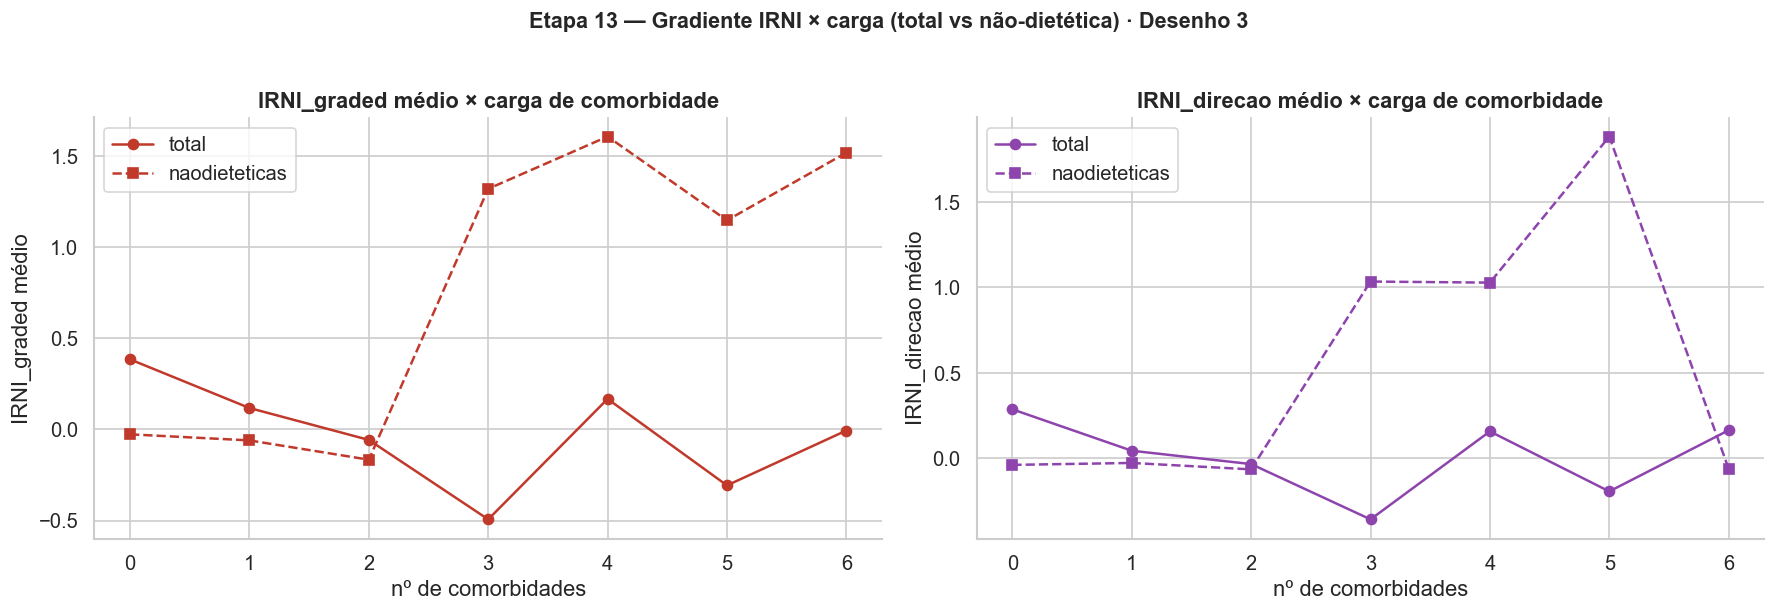

  Correlação de Spearman (IRNI × carga):
    IRNI_graded   × n_comorb_total          : rho=-0.025  p=1.08e-01
    IRNI_graded   × n_comorb_naodieteticas  : rho=+0.008  p=6.04e-01
    IRNI_direcao  × n_comorb_total          : rho=-0.023  p=1.42e-01
    IRNI_direcao  × n_comorb_naodieteticas  : rho=+0.014  p=3.73e-01


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (esq, cor) in zip(axes, [('IRNI_graded', COR_ARTRITE), ('IRNI_direcao', '#8E44AD')]):
    g = meta_out.copy(); g[esq] = df_final[esq].values
    for cont, ls, mk in [('n_comorb_total','-','o'), ('n_comorb_naodieteticas','--','s')]:
        med = g.groupby(cont)[esq].mean()
        med = med[med.index <= 6]  # caudas raras
        ax.plot(med.index, med.values, ls=ls, marker=mk, color=cor,
                label=cont.replace('n_comorb_',''))
    ax.set_title(f'{esq} médio × carga de comorbidade', fontweight='bold')
    ax.set_xlabel('nº de comorbidades'); ax.set_ylabel(f'{esq} médio'); ax.legend()
fig.suptitle('Etapa 13 — Gradiente IRNI × carga (total vs não-dietética) · Desenho 3',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); salvar_fig('etapa13_gradiente_irni_carga.png'); plt.show()

# Correlação de Spearman IRNI × carga (rápida leitura do gradiente)
from scipy import stats as _st
print('  Correlação de Spearman (IRNI × carga):')
for esq in ['IRNI_graded','IRNI_direcao']:
    v = df_final[esq].values
    for cont in ['n_comorb_total','n_comorb_naodieteticas']:
        rho, p = _st.spearmanr(v, meta_out[cont].values)
        print(f'    {esq:13s} × {cont:24s}: rho={rho:+.3f}  p={p:.2e}')

## 14 · Relatório e sumário

⚠️ **Lembrete metodológico para o artigo:** o classificador do D3 (tem-comorbidade) é desbalanceado e
confundido pelo manejo dietético; a **entrega central é o gradiente** acima. Triangular com D1/D2.

In [14]:
relatorio = {
    'projeto':'Artrite e Reumatismo em Idosos Brasileiros — PNS 2019',
    'pesquisador':'Pedro Dias Soares','orientador':'Prof. Dr. Luis Enrique Zárate — PUC Minas',
    'notebook':'03c_preprocessamento_desenho3',
    'desenho':'Desenho 3 — intra-artrite; alvo = tem >=1 comorbidade',
    'aviso':'Confundidor: dieta pode refletir manejo da comorbidade. Entrega central = gradiente IRNI x carga.',
    'parametros':{'LIMITE_MISSING_pct':LIMITE_MISSING*100,'LIMITE_IQR_MULT':LIMITE_IQR_MULT,
                  'RANDOM_STATE':RANDOM_STATE,'irni_esquemas':list(CFG['nutricao']['irni']),
                  'comorbidades_dieteticas':DIETETICAS},
    'rastreabilidade':{
        'skip_total':int(tab_skip['n_preenchidos'].sum()),
        'vars_excluidas_>75pct':vars_excluir,
        'outliers':int(tab_outliers['n_outliers'].sum()),
        'imputados':int(tab_imp['n_imputados'].sum()),
        'anti_leakage_removidas':cols_leak,
        'features_irni':['IRNI_graded','IRNI_direcao'],
        'dataset_final':{'n_registros':int(X.shape[0]),'n_features':int(X.shape[1]),
            'distribuicao_label':{str(k):int(v) for k,v in y.value_counts().items()},
            'razao':round(float(razao),2)}}}
with open(DIR_RESULTADOS + 'relatorio_preprocessamento.json','w',encoding='utf-8') as f:
    json.dump(relatorio, f, ensure_ascii=False, indent=2)
print('=' * 70)
print('  ✅  NOTEBOOK 03C — DESENHO 3 CONCLUÍDO')
print('=' * 70)
print(f'  Coorte: {X.shape[0]:,} idosos com artrite | features: {X.shape[1]} (+ IRNI)')
print(f'  Alvo (tem comorbidade): {int((y==1).sum()):,} c/comorb vs {int((y==0).sum()):,} pura')
print(f'  Anti-leakage: {len(cols_leak)} Q* fora; n_comorb e carga guardados à parte.')
print('  Próximo: NB04 (discretiza este desenho) e NB06 (cluster k-means in-fold + modelagem + gradiente).')

  ✅  NOTEBOOK 03C — DESENHO 3 CONCLUÍDO
  Coorte: 4,025 idosos com artrite | features: 67 (+ IRNI)
  Alvo (tem comorbidade): 3,434 c/comorb vs 591 pura
  Anti-leakage: 12 Q* fora; n_comorb e carga guardados à parte.
  Próximo: NB04 (discretiza este desenho) e NB06 (cluster k-means in-fold + modelagem + gradiente).
